# Lab 9- Deep Learning Model

This lab is meant to get you started in using Keras to design Deep Neural Networks. The goal here is to simply repeat your previous lab, but with DNNs.

Let's start with reading the data, like before:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

filename="/Users/tanvirsingh/Desktop/pythonlab2/DATA3402.Spring.2026/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi","MET", "MET_phi", "MET_rel", "axial_MET"]
FeatureNames=["M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

df = pd.read_csv(filename, dtype='float64', names=VarNames)

Now lets define training and test samples. Note that DNNs take very long to train, so for testing purposes we will use only about 10% of the 5 million events in the training/validation sample. Once you get everything working, make the final version of your plots with the full sample. 

Also note that Keras had trouble with the Pandas tensors, so after doing all of the nice manipulation that Pandas enables, we convert the Tensor to a regular numpy tensor.

In [38]:
from keras.models import Sequential, Model
from keras.layers import Dense, Input
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression

In [2]:
N_Max=550000
N_Train=500000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:N_Max]

X_Train=np.array(Train_Sample[VarNames[1:]])
y_Train=np.array(Train_Sample["signal"])

X_Test=np.array(Test_Sample[VarNames[1:]])
y_Test=np.array(Test_Sample["signal"])


## Exercise 1

You will need to create several models and make sure they are properly trained. Write a function that takes this history and plots the values versus epoch. For every model that you train in the remainder of this lab, assess:

* Has you model's performance plateaued? If not train for more epochs. 
* Compare the performance on training versus test sample. Are you over training?

In [8]:
## With AI assistance
def plot_history(history, title="Model Performance"):
    plt.plot(history.history["loss"], label="train loss")
    plt.plot(history.history["val_loss"], label="val loss")
    plt.legend()
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.show()

## Exercise 2

Following the original paper (see lab 7), make a comparison of the performance (using ROC curves and AUC) between models trained with raw, features, and raw+features data.

In [11]:
## Lecture 20 reference
def build_model(input_dim):
    model = Sequential()
    model.add(Dense(12, activation='relu', input_dim=input_dim))
    model.add(Dense(8, activation='relu'))
    model.add(Dense(8, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy']
    )

    return model

In [18]:
X_Train_df = Train_Sample[VarNames[1:]]
X_Test_df = Test_Sample[VarNames[1:]]

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 287us/step


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 285us/step


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 267us/step


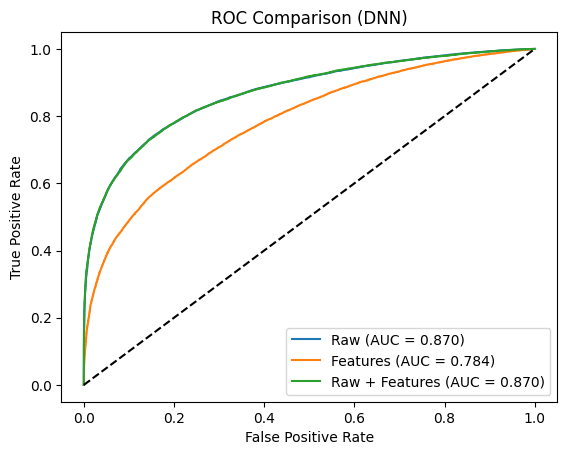

In [19]:
def train_and_roc(X_train, y_train, X_test, y_test, label):

    model = build_model(X_train.shape[1])

    model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=10,
        batch_size=2048,
        verbose=0
    )

    scores = model.predict(X_test).ravel()

    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.3f})")

plt.figure()

## Lab 8 (3b)
# Raw
train_and_roc(X_Train, y_Train, X_Test, y_Test, "Raw")

# Features
train_and_roc(
    X_Train_df[["M_R", "M_TR_2", "R"]],
    y_Train,
    X_Test_df[["M_R", "M_TR_2", "R"]],
    y_Test,
    "Features"
)

# Raw + Features
train_and_roc(X_Train.copy(), y_Train, X_Test.copy(), y_Test, "Raw + Features")

plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison (DNN)")
plt.legend()
plt.show()


Similar outcome from lab 8, Raw and Raw + Features have the same AUC, but this time the AUC slightly increased to 0.87 from 0.836. The Features alone still had the lowest AUC of 0.784, but still higher than lab 8 with 0.767. The Deep Neural Network was able to extract more informative patterns from the data compared to the linear discriminant analysis , leading to the improved separation between signal and background. This may be because DNNs are able to learn nonlinear and more complex relationships in the data.

## Exercise 3

Design and implement at least 3 different DNN models. Train them and compare performance. You may try different architectures, loss functions, and optimizers to see if there is an effect.

In [20]:
def build_model_1(input_dim):
    model = Sequential([
        Dense(12, activation='relu', input_dim=input_dim),
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [22]:
## With AI assistance (I am not fully familiar with Keras)
# Model 1: Baseline model (almost like a control)
model1 = build_model_1(X_Train.shape[1])

In [23]:
## With AI assistance
# Model 2: Same number of layers as model 1, layers are wider
def build_model_2(input_dim):
    model = Sequential([
        Dense(64, activation='relu', input_dim=input_dim),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [27]:
## With AI assistance
# Model 3: Same number of layers as model 1 and 2, layers are even wider 
def build_model_3(input_dim):
    model = Sequential([
        Dense(128, activation='relu', input_dim=input_dim),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [30]:
def train_and_roc_dnn(model, X_train, y_train, X_test, y_test, label):

    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=10,
        batch_size=2048,
        verbose=0
    )

    scores = model.predict(X_test).ravel() # ravel() used to convert output into 1D array

    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{label} (AUC={roc_auc:.3f})")

    return history, roc_auc

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 271us/step


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 272us/step


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 288us/step


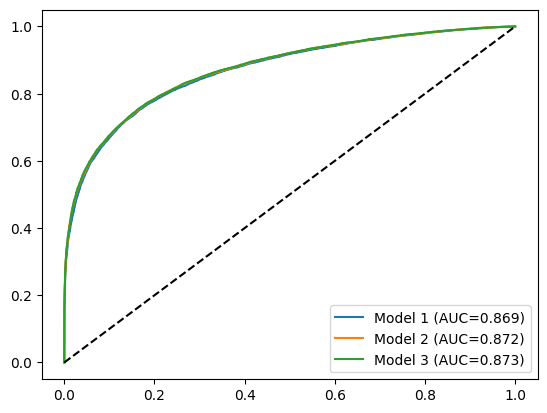

In [29]:
plt.figure()

h1, a1 = train_and_roc_dnn(build_model_1(X_Train.shape[1]), X_Train, y_Train, X_Test, y_Test, "Model 1")
h2, a2 = train_and_roc_dnn(build_model_2(X_Train.shape[1]), X_Train, y_Train, X_Test, y_Test, "Model 2")
h3, a3 = train_and_roc_dnn(build_model_3(X_Train.shape[1]), X_Train, y_Train, X_Test, y_Test, "Model 3")

plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.show()

From only adjusting the width of the layers of each model, the AUC does increase slighty. For Model 1, AUC equals 0.869, Model 2 AUC is 0.872, and Model 3 AUC is 0.873. Overall, increasing the model width provides only a small improvemnt in performance, suggesting that the model is already close to plateuing its ability to identify signal from background.

In [31]:
# What if we increased the width and depth?
def build_model_4(input_dim):
    model = Sequential([
        Dense(128, activation='relu', input_dim=input_dim),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 317us/step


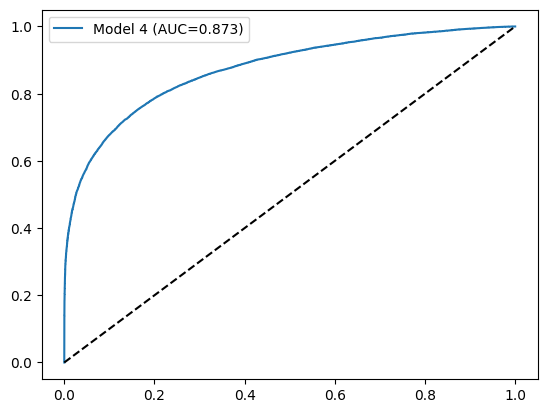

In [33]:
plt.figure()

h1, a1 = train_and_roc_dnn(build_model_4(X_Train.shape[1]), X_Train, y_Train, X_Test, y_Test, "Model 4")

plt.plot([0,1],[0,1],'k--')
plt.legend()
plt.show()

From model 4, I increased the width and depth, which did not produce any substatial change. The model has reach its limits in separating signal from background when its AUC is around 0.873, which is similar to Model 3.

## Exercise 4

Repeat exercise 4 from Lab 8, adding your best performing DNN as one of the models.  


I chose Model 3 instead of Model 4, since it was a simpler model that achieved the same performance as Model 4.

In [34]:
## From Lab 8

def plot_roc(model, X_test, y_test, label):
    scores = model.predict(X_test).ravel()
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.3f})")
    return roc_auc

In [39]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_Train, y_Train)
lr_scores = lr.decision_function(X_Test)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 291us/step


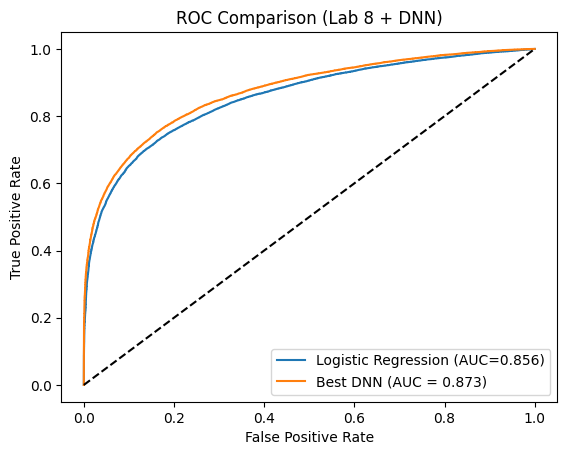

In [40]:
plt.figure()

# Logistic Regression (Lab 8)
fpr_lr, tpr_lr, _ = roc_curve(y_Test, lr_scores)
auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={auc_lr:.3f})")

# Model 3 (Best DNN)
dnn = build_model_3(X_Train.shape[1])
dnn.fit(X_Train, y_Train, epochs=10, batch_size=2048, verbose=0)

dnn_auc = plot_roc(dnn, X_Test, y_Test, "Best DNN")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison (Lab 8 + DNN)")
plt.legend()
plt.show()

Compared to logistic regression, the DNN model achieved a higher AUC of 0.873 compared to 0.853. This shows that DNN models provide a slight improvement over even the best linear models from scikit-learn. The DNN is able to better capture the nonlinear relationships in the data that are not fully captured by the linear logistic regression model.

In [41]:
## From lab 8
scores = dnn.predict(X_Test).ravel()

thresholds = np.percentile(scores, np.linspace(0.01, 0.99, 200))

best_sigma = 0
best_t = 0

for t in thresholds:
    pred = scores > t
    
    N_S = np.sum((pred == 1) & (y_Test == 1))
    N_B = np.sum((pred == 1) & (y_Test == 0))

    if (N_S + N_B) == 0:
        continue
    
    sigma = N_S / np.sqrt(N_S + N_B)
        
    if sigma > best_sigma:
        best_sigma = sigma
        best_t = t

print("Best threshold:", best_t)
print("Max significance:", best_sigma)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 1s 314us/step
Best threshold: 0.0431781230442226
Max significance: 103.33164161461794


Despite AUC of the DNN model being higher that for the logistic regression model, its best threshold and max significance are lower. This means that the DNN does well in overall ranking performance, but does not provide a more optimal signal significance as logistic regression does. The DNN best threshold is 0.04 compared to log reg's 0.05. This is a slight decrease but does point out that DNN also provides a more lenient classification boundary in determining signal from the background. The DNN max significance is 103, compared to log reg's 460, meaning that the DNN yields a lot more background events relative to signal.